In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
df = pd.read_csv("https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv")
df.head(1)

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9


In [23]:
selection = ['engine_displacement','horsepower','vehicle_weight','model_year','fuel_efficiency_mpg']
df = df[selection]
df.head(1)

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9


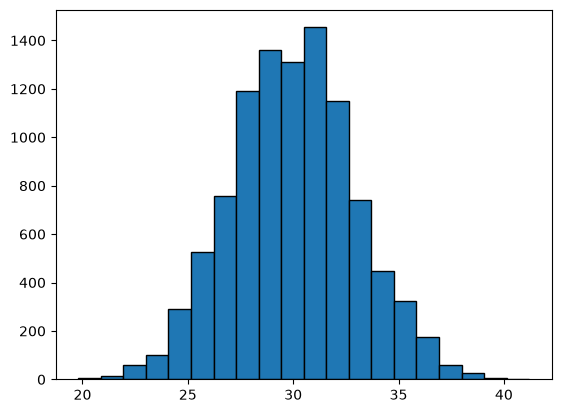

In [24]:
plt.hist(df['fuel_efficiency_mpg'], bins=20, edgecolor='black')
plt.show()

In [25]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [26]:
df['horsepower'].describe()

count    9123.000000
mean      254.446016
std        22.844613
min       171.000000
25%       239.000000
50%       254.000000
75%       270.000000
max       334.000000
Name: horsepower, dtype: float64

In [27]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

### Fill NA values with 0

In [34]:
df2 = df.copy()

In [29]:
df2.horsepower = df2.horsepower.fillna(0)

In [30]:
n = len(df2)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [31]:
# Separar target (fuel_efficiency_mpg) de cada dataset para regresión lineal

X_train = df_train.drop(columns=['fuel_efficiency_mpg'])
y_train = df_train['fuel_efficiency_mpg']

X_val = df_val.drop(columns=['fuel_efficiency_mpg'])
y_val = df_val['fuel_efficiency_mpg']

X_test = df_test.drop(columns=['fuel_efficiency_mpg'])
y_test = df_test['fuel_efficiency_mpg']

# Verificar shapes
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

X_train: (6000, 4) y_train: (6000,)
X_val: (2000, 4) y_val: (2000,)
X_test: (2000, 4) y_test: (2000,)


In [33]:
# Agrega el intercepto y ajusta la regresión lineal con mínimos cuadrados.
X_train_bias = np.column_stack([np.ones(len(X_train)), X_train.to_numpy()])
X_val_bias = np.column_stack([np.ones(len(X_val)), X_val.to_numpy()])

X_train_bias = np.column_stack([np.ones(len(X_train_clean)), X_train_clean.to_numpy()])
X_val_bias = np.column_stack([np.ones(len(X_val_clean)), X_val_clean.to_numpy()])

coeficientes, _, _, _ = np.linalg.lstsq(X_train_bias, y_train.to_numpy(), rcond=None)

# Predice en validación y calcula el RMSE.
y_val_pred = X_val_bias @ coeficientes
rmse_val = np.sqrt(np.mean((y_val.to_numpy() - y_val_pred) ** 2))

print(f"RMSE de validación: {rmse_val:.3f}")


RMSE de validación: 2.205


### Filla NA values with mean

In [35]:
df3 = df.copy()

# Dividir los datos en train, validación y test
n = len(df3)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df3_train = df3.iloc[idx[:n_train]].copy()
df3_val = df3.iloc[idx[n_train:n_train + n_val]].copy()
df3_test = df3.iloc[idx[n_train + n_val:]].copy()

# Calcular la media solo con train y usarla para completar los valores faltantes
horsepower_mean = df3_train['horsepower'].mean()

for split in (df3_train, df3_val, df3_test):
    split['horsepower'] = split['horsepower'].fillna(horsepower_mean)

# Separar variables y target
X3_train = df3_train.drop(columns=['fuel_efficiency_mpg'])
y3_train = df3_train['fuel_efficiency_mpg']

X3_val = df3_val.drop(columns=['fuel_efficiency_mpg'])
y3_val = df3_val['fuel_efficiency_mpg']

# Entrenar la regresión lineal con intercepto
X3_train_bias = np.column_stack([np.ones(len(X3_train)), X3_train.to_numpy()])
X3_val_bias = np.column_stack([np.ones(len(X3_val)), X3_val.to_numpy()])

coeficientes3, _, _, _ = np.linalg.lstsq(
    X3_train_bias, y3_train.to_numpy(), rcond=None
)

# Predecir en validación y calcular RMSE
y3_val_pred = X3_val_bias @ coeficientes3
rmse3_val = np.sqrt(np.mean((y3_val.to_numpy() - y3_val_pred) ** 2))

print(f"Media de horsepower en train: {horsepower_mean:.2f}")
print(f"RMSE de validación: {rmse3_val:.3f}")

Media de horsepower en train: 254.46
RMSE de validación: 2.202


### Question 4

In [37]:
df2_zero = df2.fillna(0).copy()

n_ridge = len(df2_zero)
n_val_ridge = int(n_ridge * 0.2)
n_train_ridge = n_ridge - 2 * n_val_ridge

np.random.seed(42)
idx_ridge = np.arange(n_ridge)
np.random.shuffle(idx_ridge)

train_ridge = df2_zero.iloc[idx_ridge[:n_train_ridge]]
val_ridge = df2_zero.iloc[idx_ridge[n_train_ridge:n_train_ridge + n_val_ridge]]

X_train_ridge = train_ridge.drop(columns="fuel_efficiency_mpg").to_numpy()
y_train_ridge = train_ridge["fuel_efficiency_mpg"].to_numpy()
X_val_ridge = val_ridge.drop(columns="fuel_efficiency_mpg").to_numpy()
y_val_ridge = val_ridge["fuel_efficiency_mpg"].to_numpy()

X_train_ridge = np.column_stack([np.ones(len(X_train_ridge)), X_train_ridge])
X_val_ridge = np.column_stack([np.ones(len(X_val_ridge)), X_val_ridge])

r_values = [0, 0.01, 0.1, 1, 5, 10, 100]
rmse_by_r = {}

for r in r_values:
    regularization = r * np.eye(X_train_ridge.shape[1])
    coefficients = np.linalg.solve(
        X_train_ridge.T @ X_train_ridge + regularization,
        X_train_ridge.T @ y_train_ridge,
    )
    predictions = X_val_ridge @ coefficients
    rmse_by_r[r] = round(np.sqrt(np.mean((y_val_ridge - predictions) ** 2)), 4)

rmse_results = pd.Series(rmse_by_r, name="validation_rmse")
print("RMSE values sorted from lowest to highest:")
for r, rmse in sorted(rmse_by_r.items(), key=lambda item: item[1]):
    print(f"r={r}: RMSE={rmse:.4f}")

best_r = rmse_results.idxmin()
print(f"\nBest r: {best_r}, validation RMSE: {rmse_results[best_r]:.4f}")


RMSE values sorted from lowest to highest:
r=0: RMSE=2.2053
r=0.01: RMSE=2.2058
r=0.1: RMSE=2.2241
r=1: RMSE=2.3492
r=5: RMSE=2.4094
r=10: RMSE=2.4195
r=100: RMSE=2.4292

Best r: 0.0, validation RMSE: 2.2053


### Question 5

In [38]:
seed_scores = []

for seed in range(10):
    seed_rng = np.random.RandomState(seed)
    shuffled_indices = seed_rng.permutation(len(df))

    n_train_seed = int(len(df) * 0.6)
    n_val_seed = int(len(df) * 0.2)

    train_seed = df.iloc[shuffled_indices[:n_train_seed]].fillna(0)
    val_seed = df.iloc[shuffled_indices[n_train_seed:n_train_seed + n_val_seed]].fillna(0)

    X_train_seed = train_seed.drop(columns="fuel_efficiency_mpg").to_numpy()
    y_train_seed = train_seed["fuel_efficiency_mpg"].to_numpy()
    X_val_seed = val_seed.drop(columns="fuel_efficiency_mpg").to_numpy()
    y_val_seed = val_seed["fuel_efficiency_mpg"].to_numpy()

    X_train_seed = np.column_stack([np.ones(len(X_train_seed)), X_train_seed])
    X_val_seed = np.column_stack([np.ones(len(X_val_seed)), X_val_seed])

    coefficients_seed, _, _, _ = np.linalg.lstsq(
        X_train_seed, y_train_seed, rcond=None
    )
    predictions_seed = X_val_seed @ coefficients_seed
    seed_scores.append(np.sqrt(np.mean((y_val_seed - predictions_seed) ** 2)))

std = np.std(seed_scores)
print(round(std, 3))

0.029


### Question 6

In [ ]:
seed_rng = np.random.RandomState(9)
shuffled_indices = seed_rng.permutation(len(df))

n_train = int(len(df) * 0.6)
n_val = int(len(df) * 0.2)

train_val = df.iloc[shuffled_indices[:n_train + n_val]].fillna(0)
test = df.iloc[shuffled_indices[n_train + n_val:]].fillna(0)

X_train_val = train_val.drop(columns="fuel_efficiency_mpg").to_numpy()
y_train_val = train_val["fuel_efficiency_mpg"].to_numpy()
X_test_seed9 = test.drop(columns="fuel_efficiency_mpg").to_numpy()
y_test_seed9 = test["fuel_efficiency_mpg"].to_numpy()

X_train_val = np.column_stack([np.ones(len(X_train_val)), X_train_val])
X_test_seed9 = np.column_stack([np.ones(len(X_test_seed9)), X_test_seed9])

r = 0.001
regularization = r * np.eye(X_train_val.shape[1])

coefficients_seed9 = np.linalg.solve(
    X_train_val.T @ X_train_val + regularization,
    X_train_val.T @ y_train_val,
)

test_predictions_seed9 = X_test_seed9 @ coefficients_seed9
test_rmse_seed9 = np.sqrt(np.mean((y_test_seed9 - test_predictions_seed9) ** 2))

print(f"Test RMSE: {test_rmse_seed9:.4f}")